In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('dataset_phishing.csv')

In [3]:
df.head()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [4]:
df.shape

(11430, 89)

In [5]:
# Features selected based on correlation and URL extractability
SELECTED_FEATURES = [
    "nb_www",
    "ratio_digits_url",
    "phish_hints",
    "ip",
    "nb_qm",
    "length_url",
    "nb_slash",
    "length_hostname",
    "nb_eq",
    "ratio_digits_host",
    "shortest_word_host",
    "prefix_suffix",
    "longest_word_path",
    "tld_in_subdomain",
    "nb_dots"
]

TARGET = "status"

# Keep ONLY the selected features and target
df_selected = df[SELECTED_FEATURES + [TARGET]].copy()

print("Original dataset shape:", df.shape)
print("Selected dataset shape:", df_selected.shape)

print("\nColumns kept:")
print(df_selected.columns.tolist())

Original dataset shape: (11430, 89)
Selected dataset shape: (11430, 16)

Columns kept:
['nb_www', 'ratio_digits_url', 'phish_hints', 'ip', 'nb_qm', 'length_url', 'nb_slash', 'length_hostname', 'nb_eq', 'ratio_digits_host', 'shortest_word_host', 'prefix_suffix', 'longest_word_path', 'tld_in_subdomain', 'nb_dots', 'status']


In [6]:
df_heatmap = df_selected.copy()

df_heatmap["status"] = df_heatmap["status"].map({
    "legitimate": 0,
    "phishing": 1
})

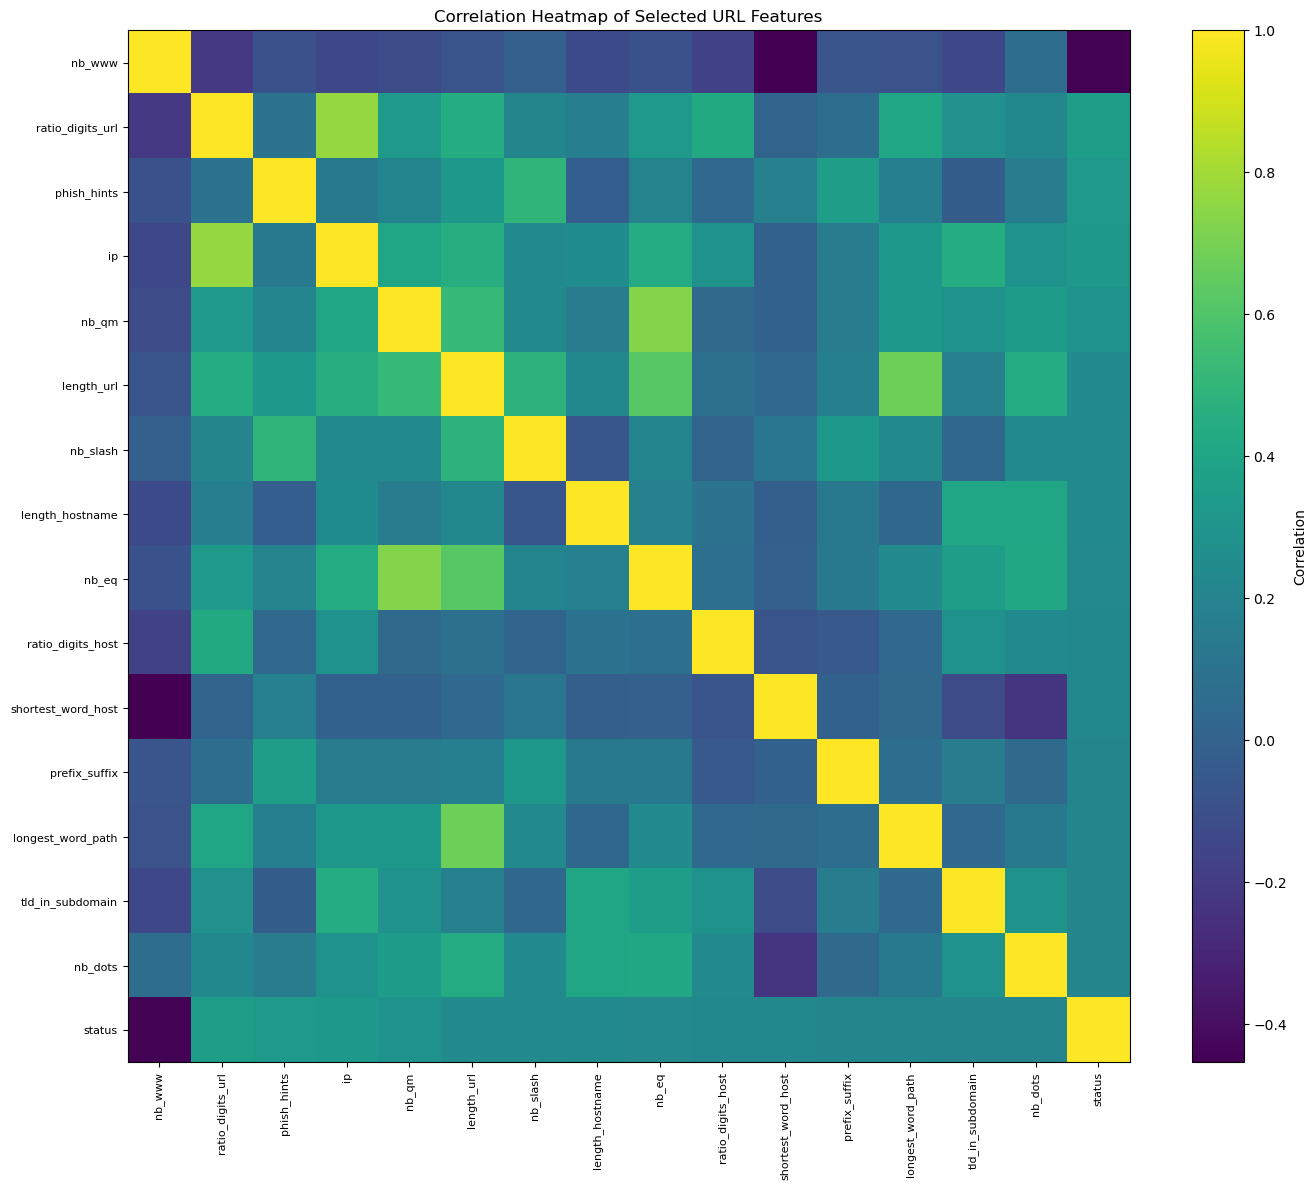

In [7]:
import matplotlib.pyplot as plt

correlation_matrix = df_heatmap.corr()

plt.figure(figsize=(14, 12))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=8
)

plt.title("Correlation Heatmap of Selected URL Features")

plt.tight_layout()

plt.show()

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [9]:
# Input features
X = df_selected[SELECTED_FEATURES].copy()

# Target
y = df_selected[TARGET].copy()

# Convert target labels to numbers
# legitimate = 0
# phishing = 1
y = y.map({
    "legitimate": 0,
    "phishing": 1
})

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (11430, 15)
y shape: (11430,)

Target distribution:
status
0    5715
1    5715
Name: count, dtype: int64


In [10]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
nb_www                0
ratio_digits_url      0
phish_hints           0
ip                    0
nb_qm                 0
length_url            0
nb_slash              0
length_hostname       0
nb_eq                 0
ratio_digits_host     0
shortest_word_host    0
prefix_suffix         0
longest_word_path     0
tld_in_subdomain      0
nb_dots               0
dtype: int64

Missing values in y:
0


In [11]:
X = X.astype(np.float32)
y = y.astype(np.float32)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 10287
Testing samples: 1143


In [13]:
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for test data
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values.reshape(-1, 1),
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values.reshape(-1, 1),
    dtype=torch.float32
)

print("Training tensor shape:", X_train_tensor.shape)
print("Target tensor shape:", y_train_tensor.shape)

Training tensor shape: torch.Size([10287, 15])
Target tensor shape: torch.Size([10287, 1])


In [15]:
class LogisticRegressionModel(nn.Module):

    def __init__(self, input_size):
        super(LogisticRegressionModel, self).__init__()

        self.linear = nn.Linear(
            input_size,
            1
        )

    def forward(self, x):
        return self.linear(x)

In [17]:
logisticmodel = LogisticRegressionModel(
    input_size=len(SELECTED_FEATURES)
)

print(logisticmodel)

LogisticRegressionModel(
  (linear): Linear(in_features=15, out_features=1, bias=True)
)


In [19]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    logisticmodel.parameters(),
    lr=0.001
)

In [20]:
num_epochs = 10000

loss_history = []

for epoch in range(num_epochs):

    # ----------------------------
    # Forward propagation
    # ----------------------------

    logits = logisticmodel(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )


    # ----------------------------
    # Backpropagation
    # ----------------------------

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    # Save loss for plotting
    loss_history.append(loss.item())


    # Print progress
    if (epoch + 1) % 50 == 0:

        print(
            f"Epoch [{epoch + 1}/{num_epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [50/10000], Loss: 0.6457
Epoch [100/10000], Loss: 0.5892
Epoch [150/10000], Loss: 0.5520
Epoch [200/10000], Loss: 0.5262
Epoch [250/10000], Loss: 0.5076
Epoch [300/10000], Loss: 0.4937
Epoch [350/10000], Loss: 0.4830
Epoch [400/10000], Loss: 0.4745
Epoch [450/10000], Loss: 0.4676
Epoch [500/10000], Loss: 0.4620
Epoch [550/10000], Loss: 0.4572
Epoch [600/10000], Loss: 0.4531
Epoch [650/10000], Loss: 0.4495
Epoch [700/10000], Loss: 0.4464
Epoch [750/10000], Loss: 0.4436
Epoch [800/10000], Loss: 0.4410
Epoch [850/10000], Loss: 0.4387
Epoch [900/10000], Loss: 0.4366
Epoch [950/10000], Loss: 0.4346
Epoch [1000/10000], Loss: 0.4328
Epoch [1050/10000], Loss: 0.4311
Epoch [1100/10000], Loss: 0.4295
Epoch [1150/10000], Loss: 0.4280
Epoch [1200/10000], Loss: 0.4266
Epoch [1250/10000], Loss: 0.4253
Epoch [1300/10000], Loss: 0.4240
Epoch [1350/10000], Loss: 0.4228
Epoch [1400/10000], Loss: 0.4217
Epoch [1450/10000], Loss: 0.4207
Epoch [1500/10000], Loss: 0.4197
Epoch [1550/10000], Loss: 0.41

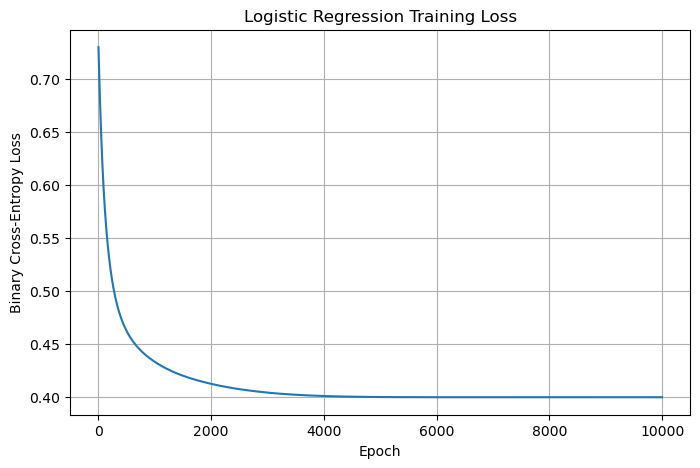

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title("Logistic Regression Training Loss")

plt.grid()

plt.show()

In [26]:
logisticmodel.eval()

with torch.no_grad():

    # Get raw outputs
    logits = logisticmodel(X_test_tensor)

    # Convert logits to probabilities
    probabilities = torch.sigmoid(logits)

    # Convert probabilities into classes
    predictions = (
        probabilities >= 0.5
    ).float()

In [27]:
y_pred = predictions.cpu().numpy().flatten()
y_true = y_test_tensor.cpu().numpy().flatten()

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print("Logistic Regression Results")
print("=" * 40)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Logistic Regression Results
Accuracy:  0.8268
Precision: 0.8397
Recall:    0.8074
F1 Score:  0.8232


In [29]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[484  88]
 [110 461]]


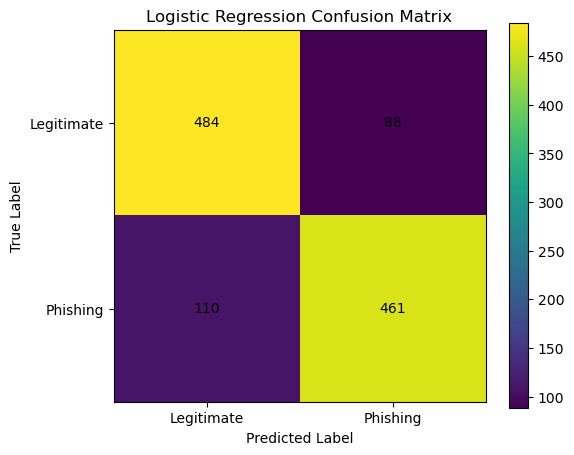

In [30]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Legitimate", "Phishing"]
)

plt.yticks(
    [0, 1],
    ["Legitimate", "Phishing"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Logistic Regression Confusion Matrix")

# Add numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )

plt.show()

In [35]:
import os
import joblib

os.makedirs("models/logisticregression", exist_ok=True)

# Save PyTorch model weights
torch.save(
    logisticmodel.state_dict(),
    "models/logisticregression/logistic_regression_url.pth"
)

# Save scaler
joblib.dump(
    scaler,
    "models/logisticregression/url_scaler.pkl"
)

# Save feature order
joblib.dump(
    SELECTED_FEATURES,
    "models/logisticregression/selected_features.pkl"
)

['models/logisticregression/selected_features.pkl']